In [21]:
from matplotlib import pyplot as plt 
from scipy.optimize import minimize
from scipy.special import logsumexp
import numpy as np

# Visualization; not really needed
# import treescope
# treescope.register_autovisualize_magic()

Optimization success: True
Final loss: 0.2948518046701096
Estimated W: [[-2.20207789  0.22529769  1.97678019]]
Estimated b: [ 0.00479352 -0.38187654  0.37708302]


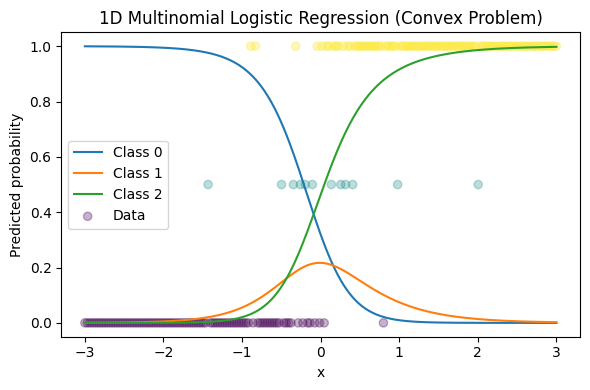

In [39]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
import matplotlib.pyplot as plt

# 1D multinomial logistic regression setup
np.random.seed(0)
n_samples = 200
n_features = 1
n_classes = 3

# True parameters for data generation
W_true = np.array([[ -2.0, 0.0, 2.0 ]])   # shape (1, 3)
b_true = np.array([0.0, 0.0, 0.0])

X = np.linspace(-3, 3, n_samples).reshape(-1, 1)
logits = X @ W_true + b_true
y_prob = softmax(logits, axis=1)
y = np.array([np.random.choice(n_classes, p=p) for p in y_prob])

# Flatten parameters for optimization
def unpack(w):
    W = w[:n_features * n_classes].reshape(n_features, n_classes)
    b = w[n_features * n_classes:]
    return W, b

def loss_fn(w):
    W, b = unpack(w)
    logits = X @ W + b
    log_probs = logits - logsumexp(logits, axis=1, keepdims=True)
    return -np.mean(log_probs[np.arange(n_samples), y])

def grad_fn(w):
    W, b = unpack(w)
    logits = X @ W + b
    probs = softmax(logits, axis=1)
    grad_W = X.T @ (probs - np.eye(n_classes)[y]) / n_samples
    grad_b = np.mean(probs - np.eye(n_classes)[y], axis=0)
    return np.concatenate([grad_W.ravel(), grad_b])

# Initialize parameters
w0 = np.zeros(n_features * n_classes + n_classes)

# Optimize (convex problem)
res = minimize(loss_fn, w0, jac=grad_fn, method="L-BFGS-B")
W_opt, b_opt = unpack(res.x)

print("Optimization success:", res.success)
print("Final loss:", res.fun)
print("Estimated W:", W_opt)
print("Estimated b:", b_opt)

# Plot probabilities
xx = np.linspace(-3, 3, 300).reshape(-1, 1)
probs = softmax(xx @ W_opt + b_opt, axis=1)
plt.figure(figsize=(6, 4))
for k in range(n_classes):
    plt.plot(xx, probs[:, k], label=f"Class {k}")
plt.scatter(X, y / (n_classes - 1), c=y, cmap="viridis", alpha=0.3, label="Data")
plt.xlabel("x")
plt.ylabel("Predicted probability")
plt.title("1D Multinomial Logistic Regression (Convex Problem)")
plt.legend()
plt.tight_layout()
plt.show()
